================= BAGGING AND BOOSTING - BREAST CANCER DATASET =================

First 5 rows of the dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430 

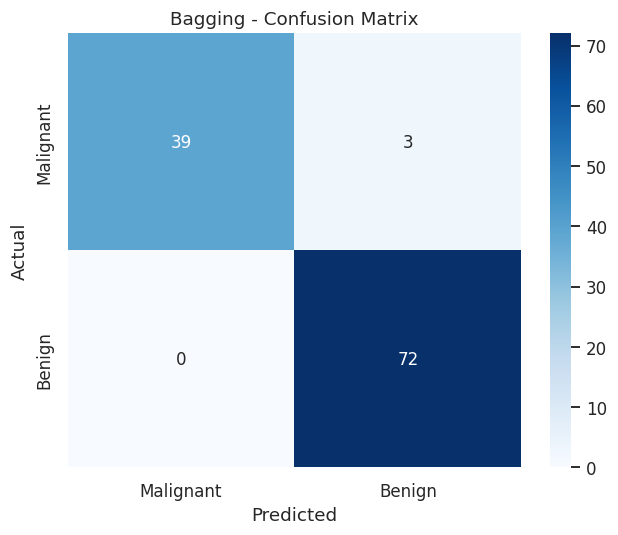


=================================== BOOSTING ===================================

Boosting Accuracy :
0.9824561403508771

Boosting Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



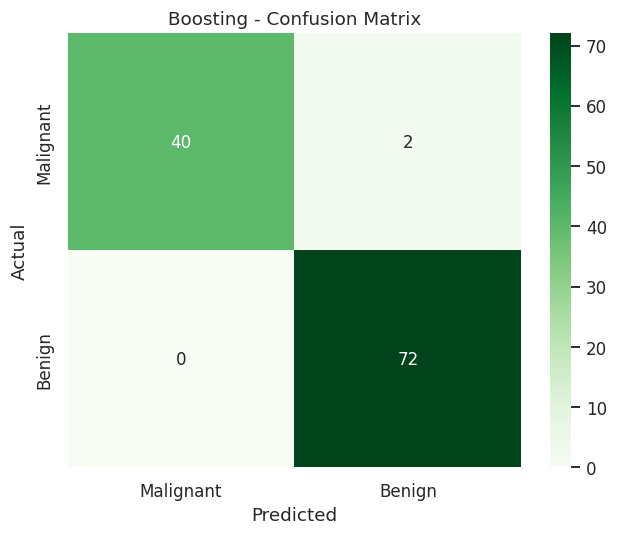


=============================== MODEL COMPARISON ===============================
   Model  Accuracy  Precision  Recall  F1 Score
 Bagging    0.9737      0.960     1.0    0.9796
Boosting    0.9825      0.973     1.0    0.9863


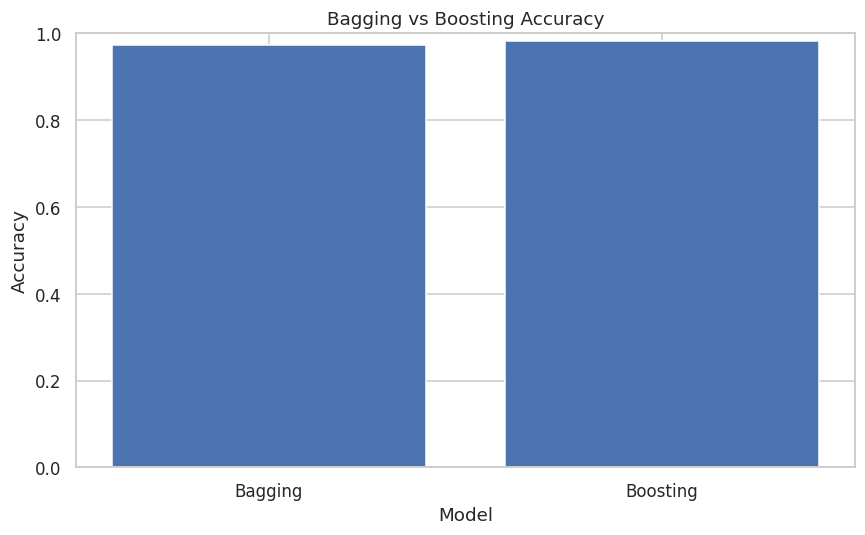

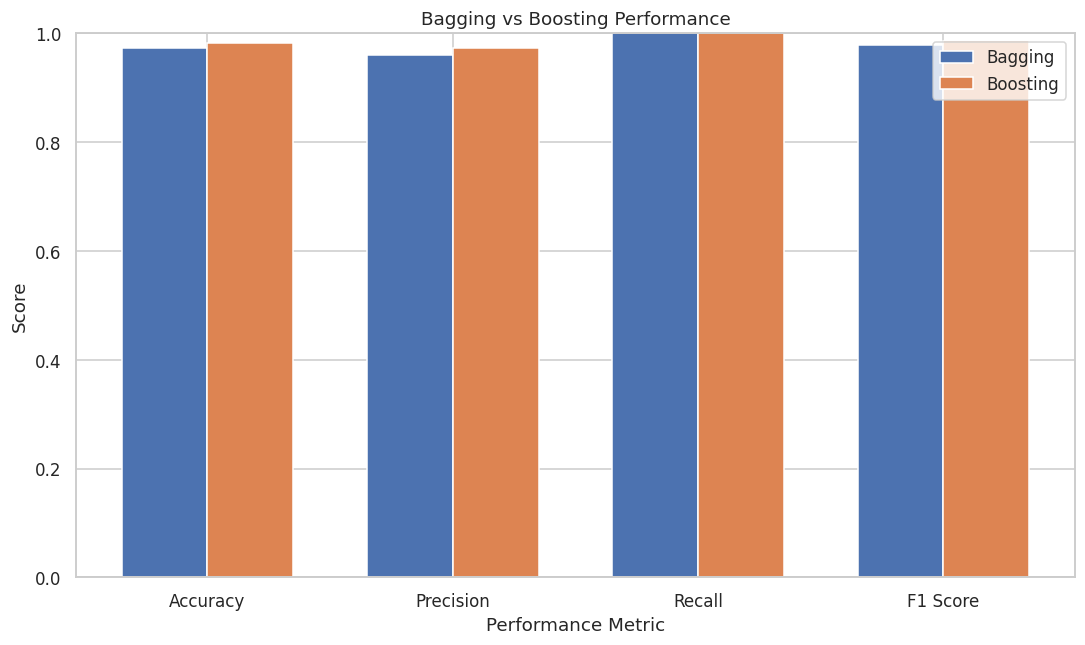


================================ FINAL SUMMARY =================================

1. Breast Cancer dataset was loaded.
2. The dataset was divided into training and testing sets.
3. A Decision Tree was used as the base classifier.
4. Bagging created multiple models using bootstrap samples and combined their predictions.
5. Boosting built weak learners sequentially, giving more importance to difficult examples.

Bagging Accuracy   : 0.9737
Boosting Accuracy  : 0.9825

================================ END OF PROGRAM ================================


In [2]:
# ============================================================================

# BAGGING AND BOOSTING USING BREAST CANCER DATASET

# Google Colab / Jupyter Ready

# ============================================================================

# ============================================================================

# SECTION 1 : IMPORT LIBRARIES

# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
BaggingClassifier,
AdaBoostClassifier
)

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
classification_report
)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

# ============================================================================

# SECTION 2 : LOAD DATASET

# ============================================================================

cancer = load_breast_cancer()

X = pd.DataFrame(
cancer.data,
columns=cancer.feature_names
)

y = pd.Series(
cancer.target,
name="Target"
)

# Convert target numbers into readable class names

y = y.map({
0: "Malignant",
1: "Benign"
})

# ============================================================================

# SECTION 3 : DISPLAY DATASET

# ============================================================================

print("=" * 80)
print(" BAGGING AND BOOSTING - BREAST CANCER DATASET ".center(80, "="))
print("=" * 80)

print("\nFirst 5 rows of the dataset:")

print(X.head())

print("\nTarget values:")

print(y.head())

print("\nDataset Shape:")
print(X.shape)

print("\nNumber of Features:")
print(X.shape[1])

print("\nClass Distribution:")
print(y.value_counts())

# ============================================================================

# SECTION 4 : TRAIN / TEST SPLIT

# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

print("\n" + "=" * 80)
print(" TRAIN / TEST SPLIT ".center(80, "="))
print("=" * 80)

print("\nTraining samples :", len(X_train))
print("Testing samples  :", len(X_test))

# ============================================================================

# SECTION 5 : BAGGING

# ============================================================================

print("\n" + "=" * 80)
print(" BAGGING ".center(80, "="))
print("=" * 80)

# Base classifier

base_tree_bagging = DecisionTreeClassifier(
random_state=42
)

# Bagging classifier

bagging_model = BaggingClassifier(
estimator=base_tree_bagging,
n_estimators=50,
random_state=42
)

# Train the model

bagging_model.fit(
X_train,
y_train
)

# Make predictions

bagging_predictions = bagging_model.predict(
X_test
)

# Calculate accuracy

bagging_accuracy = accuracy_score(
y_test,
bagging_predictions
)

print("\nBagging Accuracy :")
print(bagging_accuracy)

# Classification report

print("\nBagging Classification Report:")

print(
classification_report(
y_test,
bagging_predictions
)
)

# ============================================================================

# SECTION 6 : BAGGING CONFUSION MATRIX

# ============================================================================

bagging_cm = confusion_matrix(
y_test,
bagging_predictions,
labels=["Malignant", "Benign"]
)

plt.figure(
figsize=(6, 5)
)

sns.heatmap(
bagging_cm,
annot=True,
fmt="d",
cmap="Blues",
xticklabels=["Malignant", "Benign"],
yticklabels=["Malignant", "Benign"]
)

plt.title(
"Bagging - Confusion Matrix"
)

plt.xlabel(
"Predicted"
)

plt.ylabel(
"Actual"
)

plt.tight_layout()

plt.show()

# ============================================================================

# SECTION 7 : BOOSTING

# ============================================================================

print("\n" + "=" * 80)
print(" BOOSTING ".center(80, "="))
print("=" * 80)

# Base classifier for boosting

base_tree_boosting = DecisionTreeClassifier(
max_depth=1,
random_state=42
)

# AdaBoost classifier

boosting_model = AdaBoostClassifier(
estimator=base_tree_boosting,
n_estimators=50,
learning_rate=1.0,
random_state=42
)

# Train the model

boosting_model.fit(
X_train,
y_train
)

# Make predictions

boosting_predictions = boosting_model.predict(
X_test
)

# Calculate accuracy

boosting_accuracy = accuracy_score(
y_test,
boosting_predictions
)

print("\nBoosting Accuracy :")
print(boosting_accuracy)

# Classification report

print("\nBoosting Classification Report:")

print(
classification_report(
y_test,
boosting_predictions
)
)

# ============================================================================

# SECTION 8 : BOOSTING CONFUSION MATRIX

# ============================================================================

boosting_cm = confusion_matrix(
y_test,
boosting_predictions,
labels=["Malignant", "Benign"]
)

plt.figure(
figsize=(6, 5)
)

sns.heatmap(
boosting_cm,
annot=True,
fmt="d",
cmap="Greens",
xticklabels=["Malignant", "Benign"],
yticklabels=["Malignant", "Benign"]
)

plt.title(
"Boosting - Confusion Matrix"
)

plt.xlabel(
"Predicted"
)

plt.ylabel(
"Actual"
)

plt.tight_layout()

plt.show()

# ============================================================================

# SECTION 9 : CALCULATE PERFORMANCE METRICS

# ============================================================================

# BAGGING METRICS

bagging_precision = precision_score(
y_test,
bagging_predictions,
pos_label="Benign"
)

bagging_recall = recall_score(
y_test,
bagging_predictions,
pos_label="Benign"
)

bagging_f1 = f1_score(
y_test,
bagging_predictions,
pos_label="Benign"
)

# BOOSTING METRICS

boosting_precision = precision_score(
y_test,
boosting_predictions,
pos_label="Benign"
)

boosting_recall = recall_score(
y_test,
boosting_predictions,
pos_label="Benign"
)

boosting_f1 = f1_score(
y_test,
boosting_predictions,
pos_label="Benign"
)

# ============================================================================

# SECTION 10 : MODEL COMPARISON

# ============================================================================

comparison = pd.DataFrame({
"Model": [
    "Bagging",
    "Boosting"
],

"Accuracy": [
    bagging_accuracy,
    boosting_accuracy
],

"Precision": [
    bagging_precision,
    boosting_precision
],

"Recall": [
    bagging_recall,
    boosting_recall
],

"F1 Score": [
    bagging_f1,
    boosting_f1
]

})

comparison = comparison.round(4)

print("\n" + "=" * 80)
print(" MODEL COMPARISON ".center(80, "="))
print("=" * 80)

print(
comparison.to_string(
index=False
)
)

# ============================================================================

# SECTION 11 : ACCURACY COMPARISON GRAPH

# ============================================================================

plt.figure(
figsize=(8, 5)
)

plt.bar(
comparison["Model"],
comparison["Accuracy"]
)

plt.ylim(
0,
1
)

plt.xlabel(
"Model"
)

plt.ylabel(
"Accuracy"
)

plt.title(
"Bagging vs Boosting Accuracy"
)

plt.tight_layout()

plt.show()

# ============================================================================

# SECTION 12 : ALL METRICS COMPARISON

# ============================================================================

metrics = [
"Accuracy",
"Precision",
"Recall",
"F1 Score"
]

x = np.arange(
len(metrics)
)

width = 0.35

plt.figure(
figsize=(10, 6)
)

plt.bar(
x - width / 2,
comparison.iloc[0][metrics],
width,
label="Bagging"
)

plt.bar(
x + width / 2,
comparison.iloc[1][metrics],
width,
label="Boosting"
)

plt.xticks(
x,
metrics
)

plt.ylim(
0,
1
)

plt.xlabel(
"Performance Metric"
)

plt.ylabel(
"Score"
)

plt.title(
"Bagging vs Boosting Performance"
)

plt.legend()

plt.tight_layout()

plt.show()

# ============================================================================

# SECTION 13 : FINAL SUMMARY

# ============================================================================

print("\n" + "=" * 80)
print(" FINAL SUMMARY ".center(80, "="))
print("=" * 80)

print(
"\n1. Breast Cancer dataset was loaded."
)

print(
"2. The dataset was divided into training and testing sets."
)

print(
"3. A Decision Tree was used as the base classifier."
)

print(
"4. Bagging created multiple models using bootstrap samples "
"and combined their predictions."
)

print(
"5. Boosting built weak learners sequentially, giving more "
"importance to difficult examples."
)

print(
"\nBagging Accuracy   : %.4f"
% bagging_accuracy
)

print(
"Boosting Accuracy  : %.4f"
% boosting_accuracy
)

print("\n" + "=" * 80)
print(" END OF PROGRAM ".center(80, "="))
print("=" * 80)
